<a href="https://colab.research.google.com/github/six-eyes-dev/100-days-of-ml/blob/main/Simple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression

### What are we trying to learn?

We have:
- **One input feature (X):** CGPA
- **One target (y):** Package

Goal:

> Learn the relationship between CGPA and Package so that we can predict
> the package for a new CGPA.

Simple Linear Regression tries to learn:

y = wx + b

where:
- x = input feature
- y = predicted target
- w = weight/slope
- b = bias/intercept

## Import libraries


In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Import dataset

In [104]:
df = pd.read_csv('/content/placement.csv')

In [105]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


## 1. Know the Data

Before building a model, we first understand our dataset.

Questions we want to answer:

1. How many rows and columns do we have?
2. What are the columns?
3. Are there missing values?
4. What type of data do we have?
5. What does the distribution look like?
6. Is there a relationship between X and y?

In [106]:
df.shape

(200, 2)

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [108]:
df.describe()

,cgpa,package
count,200.000000,200.000000
mean,6.990500,2.996050
std,1.069409,0.691644
min,4.260000,1.370000
25%,6.190000,2.487500
50%,6.965000,2.995000
75%,7.737500,3.492500
max,9.580000,4.620000


In [109]:
df.duplicated().sum()

np.int64(0)

In [110]:
df.corr(numeric_only=True)

,cgpa,package
cgpa,1.000000,0.880692
package,0.880692,1.000000


### Conclusions
- No duplicates
- No null rows
- linear regression problem
- data imabalance -> not applicable.
- clearly no outliers look below.

### Correlation

Correlation tells us how strongly two numerical variables move
together linearly.

Range:

- +1 → strong positive linear relationship
-  0 → little/no linear relationship
- -1 → strong negative linear relationship

Here:

CGPA ↗ → Package ↗

The correlation is approximately 0.88, which indicates a strong
positive linear relationship.

Important:
Correlation does NOT prove causation.

### Is the data imbalanced?

Class imbalance is mainly a concern for classification problems,
where we have categories such as:

- Yes / No
- Spam / Not Spam
- Disease / No Disease

Our target (`package`) is a continuous numerical value.

Therefore, classification-style class imbalance is not applicable here.

<Axes: ylabel='cgpa'>

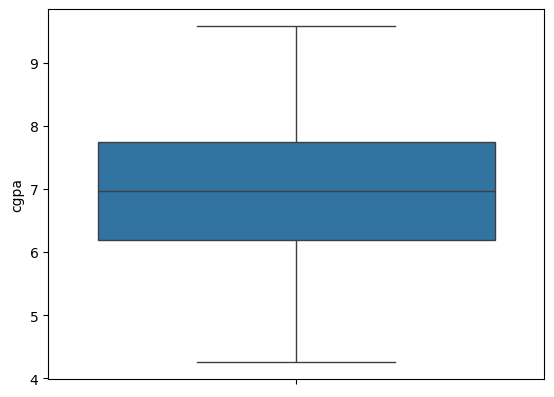

In [111]:
sns.boxplot(df, y='cgpa')

<Axes: ylabel='package'>

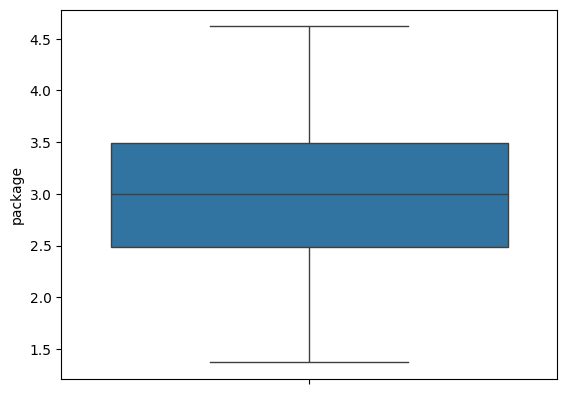

In [112]:
sns.boxplot(df, y='package')

## 2. EDA

<Axes: xlabel='cgpa', ylabel='Count'>

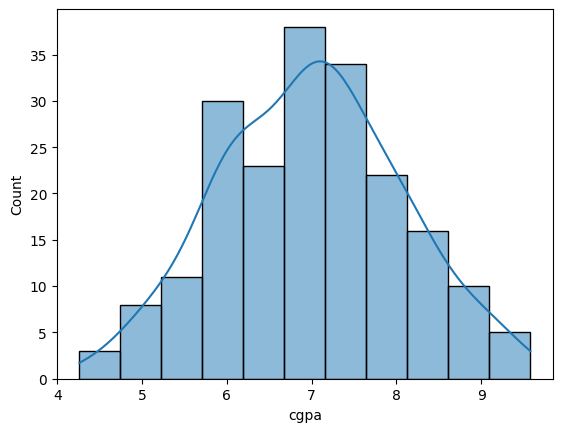

In [113]:
sns.histplot(df, x='cgpa', kde=True)

<Axes: xlabel='package', ylabel='Count'>

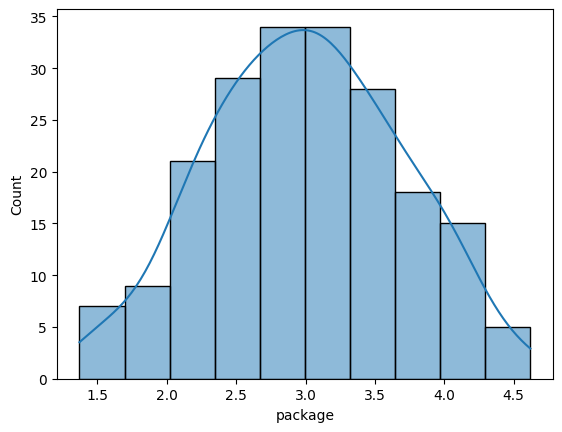

In [114]:
sns.histplot(df, x='package', kde=True)

<Axes: xlabel='cgpa', ylabel='package'>

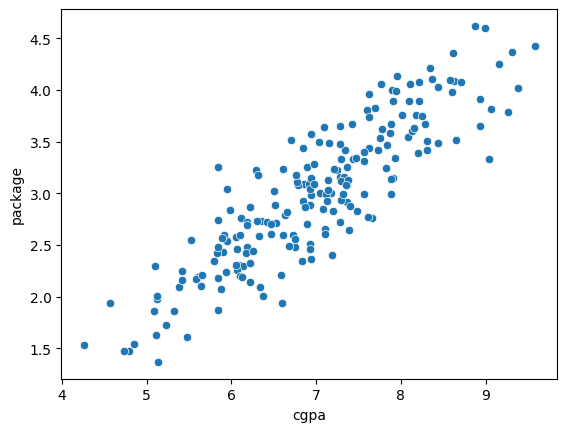

In [115]:
sns.scatterplot(df, x = 'cgpa', y = 'package')

conclusions:
- both are nearly  normal
- and having real world linear relationship

## 3. Split

In [116]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [117]:
X

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [118]:
y

,package
0,3.26
1,1.98
2,3.25
3,3.67
4,3.57
...,...
195,2.46
196,2.57
197,3.24
198,3.96


In [119]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 4. Preprocessing

Let's check whether our data requires preprocessing.

### Missing values
> No missing values → no imputation required.

### Duplicates
> No duplicate rows → no duplicate removal required.

### Outliers
> No significant problematic outliers → no outlier treatment required.

### Feature engineering
> We are starting with a simple one-feature problem.
No additional feature is required for this example.

### Feature scaling
> We don't need scaling here.

Why?

For ordinary Linear Regression, scaling is not required for the
model to learn the relationship correctly.

So:

> No major preprocessing is required for this dataset.

## Model Training

### Understand the shape of X and y

For scikit-learn models:

- X → 2D
- y → usually 1D

X contains:
- (number of samples, number of features)

For our dataset:

- X_train.shape → (160, 1)

Meaning:

- 160 samples and 1 feature (CGPA)

- y_train.shape → (160,)

Meaning:

160 target values (Package)

So:

X → 2D → (samples, features)
y → 1D → (samples,)

In [120]:
from sklearn.linear_model import LinearRegression

linear_regression = LinearRegression()

In [121]:
linear_regression.fit(X_train, y_train)

LinearRegression()

In [122]:
X_test

,cgpa
95,6.63
15,7.25
30,7.36
158,5.95
128,7.93
115,8.35
69,7.30
170,6.22
174,7.32
45,7.87


In [123]:
y_test

,package
95,2.79
15,3.23
30,3.26
158,3.04
128,3.34
115,4.21
69,2.94
170,2.87
174,2.99
45,3.58


In [124]:
pred = linear_regression.predict(X_test.iloc[[0]])

pred


array([2.78031348])

### Why do we use `iloc[[0]]`?

`X_test.iloc[0]`
→ selects one row as a Series
→ shape: (1,)

`X_test.iloc[[0]]`
→ selects one row while keeping it as a DataFrame
→ shape: (1, 1)

The model expects X in 2D:

(number of samples, number of features)

Therefore:

1 sample × 1 feature
= (1, 1)

So we use:

X_test.iloc[[0]]

Let's plot that best fit line

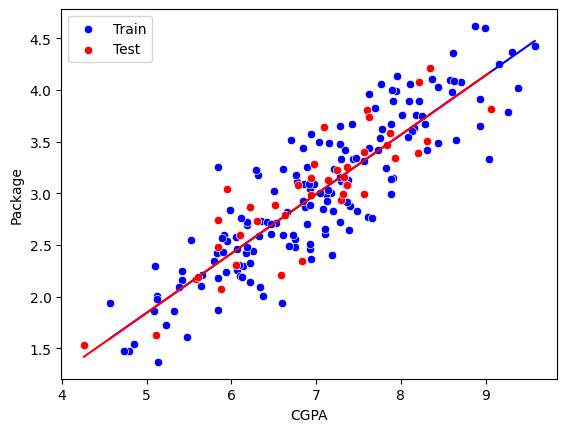

In [125]:
# Sort data for smooth regression lines
X_train_sorted = X_train.sort_values('cgpa')
X_test_sorted = X_test.sort_values('cgpa')

# Training data
sns.scatterplot(
    x=X_train['cgpa'],
    y=y_train,
    color='blue',
    label='Train'
)

sns.lineplot(
    x=X_train_sorted['cgpa'],
    y=linear_regression.predict(X_train_sorted),
    color='blue'
)

# ============================Test data======================================
sns.scatterplot(
    x=X_test['cgpa'],
    y=y_test,
    color='red',
    label='Test'
)

sns.lineplot(
    x=X_test_sorted['cgpa'],
    y=linear_regression.predict(X_test_sorted),
    color='red'
)

plt.xlabel('CGPA')
plt.ylabel('Package')
plt.legend()
plt.show()

since it's linear regression, that is y = wx + b.   
So what our model has these values? after training?

In [126]:
w = linear_regression.coef_
b = linear_regression.intercept_

In [127]:
print("w = ", w)
print("b = ", b)

w =  [0.57425647]
b =  -1.0270069374542108


## Understanding w and b

Linear Regression learns:

y = wx + b

Our model has learned two parameters:

w → slope / coefficient
b → intercept / bias

### w (weight / coefficient)

w tells us how much the predicted target changes
when x increases by 1 unit.

For example, if:

w = 0.57

then, according to the learned model:

A 1-unit increase in CGPA is associated with an
increase of approximately 0.57 in the predicted package.

### b (bias / intercept)

b is the predicted value of y when x = 0.

It is where the regression line intersects the y-axis.

Therefore:

prediction = w × CGPA + b